### Imports

In [135]:
import copy as cp
import numpy as np
import pandas as pd
import sklearn as skl
import skimage as ski
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt

### Constant, Variable, and DataFrame Instatiation

In [136]:
PALLET_DIMS = (1000, 1400, 1400)                                                # Length, width, height (X, Y, Z, respectively) in mm
DEFAULT_MAX_ATTEMPTS = 2000                                                     # Default cutoff for random attempts to place boxes
DEFAULT_CRITERION = "v"               # "x", "y", "z", "a", "v"                 # Default criterion for box sorting. OPTIONS: x - length, y - width, z - height, a - area (x*y), v - volume (x*y*z)
DEFAULT_OPTIMIZATION_METRIC = "ps"    # "ps", "vu", "cogz", "maxz"              # Default score to optimize best fit algorithms for. OPTIONS: ps - packing score, vu - volume utilization, cogz - center of gravity height, maxz - max height
ML_OBSERVATION_SCALE_FACTOR = 10                                                # Scale factor to scale down height map observations for ML model input
SUPPORTED_AREA_PERCENTAGE = 70                                                  # Percentage of pallet area that must be supported under a box for it to be placed
HOR_ROTATION_ALLOWED_DEFAULT = True                                             # Default value of whether boxes may be rotated horizontally
VER_ROTATION_ALLOWED_DEFAULT = True                                             # Default value of whether boxes may be rotated vertically

boxtypes = pd.read_csv("boxtypes.csv")                                          # Load box type dimensions
orders = pd.read_csv("orders.csv")                                              # Load orders data
test_orders = pd.read_csv("orders_test.csv")                                    # Load test orders data

#### Environment Definition

In [ ]:
class Pallet:
    # Basic functionality methods
    def __init__(self, dims=PALLET_DIMS):                                       # Initialize pallet with given dimensions
        # unpack pallet dimensions
        self.size_x, self.size_y, self.size_z = dims
        # Initialize list to store boxes placed on the pallet
        self.boxes = []
        # Initialize heightmap to track box heights at each (x, y) position
        self.heightmap = np.zeros((self.size_x, self.size_y), dtype=np.int32)
        # Initialize sets of candidate coordinates (existing box edges)
        self.candidate_x = {0}
        self.candidate_y = {0}

    def reset(self):                                                            # Emtpy the pallet
        # Clear the list of boxes
        self.boxes = []
        # Reset the heightmap to all zeros
        self.heightmap = np.zeros((self.size_x, self.size_y))
        # Reset sets of candidate coordinates
        self.candidate_x = {0}
        self.candidate_y = {0}

    # Box placement logic
    def get_in_bounds_status(self, x, y, z):                                    # Check if the given (x, y, z) position is within the pallet boundaries
        return (x <= self.size_x) and (y <= self.size_y) and (z <= self.size_z)
    
    def get_in_box_status(self, x, y, z):                                       # Check if the given (x, y, z) position is inside any box on the pallet
        for box in self.boxes:
            if (box['x'] <= x < box['x'] + box['dx'] and
                box['y'] <= y < box['y'] + box['dy'] and
                box['z'] <= z < box['z'] + box['dz']):
                return True
        return False

    def place_box(self, box_dims, x, y):                                        # Attempt to place a box of given dimensions at (x, y) position on the pallet
        # Unpack box dimensions
        dx, dy, dz = box_dims

        # Make sure x and y are ints, so we don't get partial millimeters from the model
        x = int(x)
        y = int(y)

        # Get the height the bottom of the box will be
        z = self.get_max_height_in_area(x, y, dx, dy)

        # Check if the box fits within the pallet boundaries, or return False
        if not self.get_in_bounds_status(x+dx, y+dy, z+dz):
            return False

        # Check if there is enough support under the box, or return False
        box_area = dx * dy
        area_supported = np.sum(self.heightmap[x:x+dx, y:y+dy] == z)
        support_percentage = (area_supported / box_area) * 100
        if support_percentage < SUPPORTED_AREA_PERCENTAGE:
            return False

        # Place the box: update the heightmap and store the dimensions in the boxlist
        self.heightmap[x:x+dx, y:y+dy] = z + dz
        self.boxes.append({
            'x': x, 'y': y, 'z': z, 'dx': dx, 'dy': dy, 'dz': dz
        })

        # Add box edges to candidate coordinate lists if there's space left
        if x + dx < self.size_x:
            self.candidate_x.add(x + dx)
        if y + dy < self.size_y:
            self.candidate_y.add(y + dy)

        # Return True to indicate successful placement
        return True

    # Pallet state and analysis methods    
    def get_max_height_in_area(self, x, y, dx, dy):                             # Get the maximum height in a rectangular area of the heightmap
        # Ensure we don't go out of bounds
        x_end = min(x + dx, self.size_x)                                          
        y_end = min(y + dy, self.size_y)

        # Specify the rectangle being checked
        region = self.heightmap[x:x_end, y:y_end]

        # Return -1 (fail) if the region is of size 0 or smaller
        if region.size <= 0:
            return -1
        
        # Otherwise, return the maximum height in the region
        return np.max(region)
    
    def count_boxes(self):                                                      # Return the number of boxes currently on the pallet
        return len(self.boxes)

    def get_area_usage_at_z(self, z):                                           # Return percentage of area used at specific height (z-value)
        # Get total area and initialize accumulator for used area
        total_area = self.size_x * self.size_y
        used_area_acc = 0
        
        # Check every box for intersection at chosen z, if it is, add its area to used area accumulator
        for box in self.boxes:
            box_bottom = box['z']
            box_top = box_bottom + box['dz']

            if box_bottom <= z <= box_top:
                box_area = box['dx'] * box['dy']
                used_area_acc += box_area

        # Return used/total ratio * 100 (percentage)
        return round(used_area_acc / total_area * 100, 2)

    # Pallet metrics and visualization methods
    def get_max_height(self):                                                   # Max height of boxes on the pallet, value to optimize for
        return np.max(self.heightmap)

    def check_order_fullfillment(self, orderID, order_df):                      # Check if all boxes in an order are placed on the pallet, if not, returns the percentage
        placed_box_count = self.count_boxes()
        required_box_count = len(get_box_list_from_order(orderID, order_df))
        if placed_box_count >= required_box_count:
            return True
        else:
            return round(placed_box_count / required_box_count * 100, 2)

    def visualize_heightmap(self, title, ax=None):                              # Visualize the heightmap and return as axis object
        # If no axis object is provided, create a new one
        if ax is None:
            fig, ax = plt.subplots()
        
        image = ax.imshow(self.heightmap.T, origin='lower', cmap='viridis', extent=[0, self.size_x, 0, self.size_y])
        ax.figure.colorbar(image, ax=ax, label='Height (mm)')
        ax.set_title(title)
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        
        return ax

    def visualize_boxes(self, title, ax=None):                                  # Make 3D plot of pallet and return as axis object
        # If no axis object is provided, create a new one with 3D technology
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')

        for box in self.boxes:
            # Create a 3D block for each box
            ax.bar3d(box['x'], box['y'], box['z'], box['dx'], box['dy'], box['dz'], alpha=0.7)

        # Set graph size to accurately reflect pallet dimensions
        ax.set_xlim(0, self.size_x)
        ax.set_ylim(0, self.size_y)
        ax.set_zlim(0, self.size_z)

        # Set graph labels and title
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(title)

        return ax

    def get_volume_utilization(self):                                           # Return percentage of volume (up to max used z) filled with box
        # Get ceiling and volume of considered space
        max_z = self.get_max_height()
        total_volume = self.size_x * self.size_y * max_z
        
        # Sum up the volume of every box on the pallet
        occupied_volume = 0
        for box in self.boxes:
            box_v = box['dx'] * box['dy'] * box['dz']
            occupied_volume += box_v

        return round(occupied_volume / total_volume * 100, 2)

    def get_center_of_gravity_z(self):                                          # Return the height of the average position of box volume on the pallet (as a proxy for mass, which we have no data about)
        # Initialize accumulators for total box volume and the volume-height product
        total_box_volume_acc = 0
        volume_at_height_acc = 0

        for box in self.boxes:
            # Get each box's volume and add to the total
            box_v = box['dx'] * box['dy'] * box['dz']
            total_box_volume_acc += box_v

            # Get each box's CoG by taking the bottom of the box (z) and adding half the box's height, 
            # then add the box's volume times that height to the total
            box_cog_height = box['z'] + (box['dz'] / 2)
            volume_at_height_acc += box_v * box_cog_height

        # Return -1 (fail) if no boxes are detected
        if total_box_volume_acc == 0:
            return -1
        
        # Take total volume component back out of score to get representation of height of center of gravity
        return round(volume_at_height_acc / total_box_volume_acc, 2)

    def get_packing_score(self):                                                # Calculate score (0-1, higher is better) based on per-layer utilization, each level counting less (100% at the bottom to 0% at the top of used space)
        # Initialize consideration ceiling and scores list
        max_height = self.get_max_height()
        scores = []

        # For each layer, get score factor (1-100) based on height and check space use.
        for layer in trange(max_height, leave=False, desc="Calculating packing score..."):
            score_factor = int(100 / max_height * layer)
            layer_use_percent = self.get_area_usage_at_z(layer)
            scores += [layer_use_percent] * score_factor
            
        mean_score = float(np.mean(scores))
        return round(mean_score / 100, 3)

    # ML-related methods
    def get_observation(self, scale_factor=ML_OBSERVATION_SCALE_FACTOR):        # Get a downscaled resolution view of the height map for ML
        # Use block_reduce from scikit-image to scale down heightmap, making sure to take the max so the model knows the top.
        observation = ski.measure.block_reduce(self.heightmap, block_size=(scale_factor, scale_factor), func=np.max)
        return observation

#### Helper Functions

In [138]:
def get_box_properties_from_id(boxid, df=boxtypes):                                                                                     # Retrieve length (x), width (y), height (z), area (a) and volume (v) of a box from its ID
    box = df[df['ID'] == boxid]

    x = box.iloc[0]['LENGTH']
    y = box.iloc[0]['WIDTH']
    z = box.iloc[0]['HEIGHT']

    a = x * y
    v = a * z
    
    return x, y, z, a, v

def get_box_list_from_order(orderid, df=orders):                                                                                        # Retrieve list of box IDs from a given order ID
    order = df[df['order_id'] == orderid]
    
    box_list = []

    for i in range(1, 11):
        column = f'amt_{i}'
        if column in order.columns:
            amount = order.iloc[0][column]
            for j in range(amount):
                box_list.append(i)

    return box_list

def sort_box_list_by_size(box_list, criterion=DEFAULT_CRITERION, invert=False):                                                         # Return a list of box IDs sorted by size (default = largest to smallest). Arguments: sortby to choose sorting criterion (length ("x"), width ("y"), height ("z"), area ("a"), volume ("v")), invert to sort smallest to largest, 
    # The get_box_properties_from_id function returns (x, y, z, a, v), 
    # so map sortby to the correct index of those outputs
    criterion_to_index_dict = {
        "x": 0, "length": 0,
        "y": 1, "width": 1,
        "z": 2, "height": 2,
        "a": 3, "area": 3,
        "v": 4, "volume": 4
    }

    # Make sure no bogus value is used
    if criterion not in criterion_to_index_dict:
        raise ValueError("Invalid sortby value. Use 'x', 'y', 'z', 'a', or 'v'.")

    # Sort the box list based on the chosen criterion with lambda function
    sorted_list = sorted(
        box_list, 
        key=lambda boxid: get_box_properties_from_id(boxid)[criterion_to_index_dict[criterion]], 
        reverse=not invert
    )
    
    return sorted_list
    
def process_order(order, algo, max_attempts=DEFAULT_MAX_ATTEMPTS, criterion=DEFAULT_CRITERION, metric=DEFAULT_OPTIMIZATION_METRIC, order_df=orders):     # Process a given order using the specified algorithm, max attempts, and sorting criterion
    box_list = get_box_list_from_order(order, order_df)
    pallet = Pallet()

    if algo == "random":
        place_box_list_random(pallet, box_list, max_attempts)

    elif algo == "ffd":
        place_box_list_first_fit_decreasing(pallet, box_list, criterion=criterion)

    elif algo == "bfd":
        print("Debug: Running best fit decreasing algorithm with optimization metric:", metric)
        place_box_list_best_fit_decreasing(pallet, box_list, criterion=criterion, opt_metric=metric)

    return pallet

def get_box_orientations(dx, dy, dz, rot_h=HOR_ROTATION_ALLOWED_DEFAULT, rot_v=VER_ROTATION_ALLOWED_DEFAULT):                           # Get a list of possible orientations for a box with given dimensions, based on allowed rotations
    # initialize list of valid orientations with the original orientation
    orientations = [(dx, dy, dz)]

    # If horizontal rotation is allowed, add the orientation with length and width swapped
    if rot_h:
        orientations.append((dy, dx, dz))

    # If vertical rotation is allowed, add orientations with length and height swapped, and width and height swapped
    if rot_v:
        orientations.append((dx, dz, dy))  # Width and height swapped
        orientations.append((dz, dy, dx))  # Length and height swapped

        # If both horizontal and vertical rotation are allowed, also add the orientations with both rotations applied
        if rot_h:
            orientations.append((dz, dx, dy))  # Length and height swapped, then horizontal rotation
            orientations.append((dy, dz, dx))  # Width and height swapped, then horizontal rotation
    
    return list(set(orientations))  # Remove duplicates if any rotations result in the same orientation

def get_pallet_results(pallet, algo, orderID, order_df, print_mode=False):                                                              # Get metrics for a pallet and optionally print them
    # Gather Metrics
    fulfillment = pallet.check_order_fullfillment(orderID, order_df)
    volume_util = pallet.get_volume_utilization()
    area_at_z0 = pallet.get_area_usage_at_z(0)
    cog_z = pallet.get_center_of_gravity_z()
    packing_score = pallet.get_packing_score()
    
    # Normalize full fulfillment to 100% for averaging
    if fulfillment is True:
        fulfillment = 100.0
    
    # Print metrics and visualizations if in print mode
    if print_mode:
        # Get set names from comparison of dataframes which errors when they're not the same
        try:
            if order_df == orders: 
                set_name = "Given Order List"
        except:
            set_name = "Test Order List"

        # Visualizations
        heightmap_ax = pallet.visualize_heightmap(f"Heightmap for {algo} on order {orderID} from {set_name}")
        boxes_ax = pallet.visualize_boxes(f"3D Box Visualization for {algo} on order {orderID} from {set_name}")

        # Print data
        print(f"Order fulfillment:    {fulfillment} %")
        print(f"Volume utilization:   {volume_util} %")
        print(f"Area filled at z=0:   {area_at_z0} %")
        print(f"CoG z-height:         {cog_z}")
        print(f"Packing Score:        {packing_score}")
    
    # Return metrics
    return (fulfillment, volume_util, area_at_z0, cog_z, packing_score)

#### Box Placing Algorithms

In [139]:
def place_random_boxes(pallet, num_boxes, box_size_range):                                                                          # Place a number of randomly sized boxes on the pallet
    for _ in range(num_boxes):
        # Generate random box dimensions within the specified range
        dx = np.random.randint(box_size_range[0], box_size_range[1])
        dy = np.random.randint(box_size_range[0], box_size_range[1])
        dz = np.random.randint(box_size_range[0], box_size_range[1])

        # Generate random (x, y) position for the box
        x = np.random.randint(0, pallet.size_x)
        y = np.random.randint(0, pallet.size_y)

        # Attempt to place the box on the pallet
        pallet.place_box((dx, dy, dz), x, y)

def place_box_list_random(pallet, box_list, max_attempts):                                                                          # Place boxes from a given box list randomly on the pallet
    for boxid in box_list:
        # Get box dimensions
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)

        placed = False
        attempts = 0

        while not placed and attempts < max_attempts:
            # Generate random (x, y) position for the box
            x = np.random.randint(0, pallet.size_x)
            y = np.random.randint(0, pallet.size_y)

            # Attempt to place the box on the pallet
            placed = pallet.place_box((dx, dy, dz), x, y)
            attempts += 1

def place_box_list_first_fit_decreasing(pallet, box_list, criterion=DEFAULT_CRITERION):                                             # Baseline (naive) algorithm: place boxes from a box list on the pallet, biggest boxes (by criterion x, y, z, a, or v) first, with lowest x (then y) values possible
    # Sort the box list by size (largest to smallest)
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)

    for boxid in tqdm(sorted_box_list, leave=False):
        # Get base dimensions
        original_dx, original_dy, original_dz, _, _ = get_box_properties_from_id(boxid)
        
        # Get all valid orientations for this box
        orientations = get_box_orientations(original_dx, original_dy, original_dz)

        placed = False

        # Sort candidates to ensure we pack from (0,0) outwards
        cand_x = sorted(list(pallet.candidate_x))
        cand_y = sorted(list(pallet.candidate_y))

        # Try to place box at all (x, y) candidates, and stop once the first one is found
        for x in cand_x:
            if placed: break
            for y in cand_y:
                if placed: break
                for dims in orientations:
                    if pallet.place_box(dims, x, y):
                        placed = True
                        break

def place_box_list_best_fit_decreasing(pallet, box_list, criterion=DEFAULT_CRITERION, opt_metric=DEFAULT_OPTIMIZATION_METRIC):      # Baseline (naive) algorithm: place boxes from a box list on the pallet, finding the best place for the boxes based on best value of optimization metric after placement
    # Sort the box list by size (largest to smallest)
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)

    # Define which metrics should be maximized vs minimized (higher is better vs lower is better)
    maximize_metrics = ["ps", "vu"]         # Packing Score, Volume Utilization
    minimize_metrics = ["cogz", "maxz"]     # Center of Gravity, Max Height

    for boxid in tqdm(sorted_box_list, desc="Placing boxes (Best Fit)", leave=False):
        # Get base dimensions
        original_dx, original_dy, original_dz, _, _ = get_box_properties_from_id(boxid)
        
        # Get all valid orientations for this box
        orientations = get_box_orientations(original_dx, original_dy, original_dz)

        # Initialize best score trackers for this specific box
        if opt_metric in maximize_metrics:
            best_score = -1     # Worse than any possible score as minimum for both maximization metrics is 0, making -1 a safe worst score.
        else:
            best_score = 1500   # Worse than any possible score as maximum for both minimization metrics is max z height (1400), making 1500 a safe worst score.
        
        # Initialize storage for best placement found for this box and whether one has been found
        best_placement = None
        found_valid_move = False

        # Sort candidates to ensure we check from (0,0) outwards
        cand_x = sorted(list(pallet.candidate_x))
        cand_y = sorted(list(pallet.candidate_y))

        # Check all possible placements
        for dims in orientations:
            current_dx, current_dy, current_dz = dims
            
            for x in cand_x:
                for y in cand_y:
                    # Precheck conditions for place_box() before running it to save compute
                    # Get Z height, skip to next if placement is invalid (z = -1)
                    z = pallet.get_max_height_in_area(x, y, current_dx, current_dy)
                    if z == -1: continue 

                    # Check Bounds, skip if out of bounds
                    if not pallet.get_in_bounds_status(x + current_dx, y + current_dy, z + current_dz):
                        continue

                    # Check Support, skip if not enough
                    box_area = current_dx * current_dy
                    area_supported = np.sum(pallet.heightmap[x:x+current_dx, y:y+current_dy] == z)
                    support_percentage = (area_supported / box_area) * 100
                    if support_percentage < SUPPORTED_AREA_PERCENTAGE:
                        continue

                    # If prechecks pass, create a shadow pallet to simulate the placement and calculate the resulting metric score without affecting the real pallet state
                    # Create the shadow pallet and place the box in it
                    shadow_pallet = cp.deepcopy(pallet)     # copy.deepcopy is a full independent copy rather than a (partial) symlink (https://docs.python.org/3/library/copy.html)
                    shadow_pallet.place_box(dims, x, y)
                    
                    # Calculate the score based on the chosen metric
                    score = 0
                    if opt_metric == "ps":
                        score = shadow_pallet.get_packing_score()
                    elif opt_metric == "vu":
                        score = shadow_pallet.get_volume_utilization()
                    elif opt_metric == "cogz":
                        score = shadow_pallet.get_center_of_gravity_z()
                    elif opt_metric == "maxz":
                        score = shadow_pallet.get_max_height()
                    
                    # Compare score against best found so far
                    if opt_metric in maximize_metrics:
                        if score > best_score:
                            best_score = score
                            best_placement = (dims, x, y)
                            found_valid_move = True
                    else: # Minimize metrics
                        if score < best_score:
                            best_score = score
                            best_placement = (dims, x, y)
                            found_valid_move = True

        # After finding best placement for box, place it on the real pallet if a valid move was found
        if found_valid_move and best_placement:
            b_dims, b_x, b_y = best_placement
            pallet.place_box(b_dims, b_x, b_y)
        else:
            print(f"Could not place box {boxid} anywhere.")
            pass

#### Testing Functions

In [140]:
def plot_random_performance(trials, max_max_attempts, step):                    # Plot performance of random box placement over multiple trials. Arguments: trials - amount of runs per step, max_max_attempts - maximum max_attempts value to try, step - step size between max_attempts values
    # Final lists for plotting, max_attempts values on x axis, average fullfilment on y-axis
    x_axis = [] 
    y_axis = []

    # Number of orders to cycle through
    number_of_orders = 40

    # Use max and step size to get final range of max_attempts values (x-axis)
    max_attempts_range = range(step, max_max_attempts + 1, step)

    for max_attempts in tqdm(max_attempts_range, desc="Testing max_attempts values", position=0, leave=True):
        # Keep track of scores for this max_attempts value
        scores = []

        for i in trange(trials, desc=f"Running trials (max_attempts={max_attempts})...", position=1, leave=False):
            # Pick different order every time (round robin) and get its box_list
            order_id = (i % number_of_orders) + 1
            box_list = get_box_list_from_order(order_id)

            # Initialize pallet and fill it up with the random algorithm
            pallet = Pallet()
            place_box_list_random(pallet, box_list, max_attempts)

            # Get fulfillment score (and change from True to 100 if all boxes are accounted for)
            score = pallet.check_order_fullfillment(order_id)
            if score == True:
                score = 100
            
            # Add score to scores list
            scores += [score]

        # Average the scores for this max_attempts value
        avg_score = np.mean(scores)

        # Add the datapoints to the final lists
        x_axis += [max_attempts]
        y_axis += [avg_score]

    # Plot the results
    plt.figure()
    plt.plot(x_axis, y_axis)

    plt.title(f"Random placement algorithm fulfillment scores ({trials} trials/step)")
    plt.xlabel("Maximum attempts per box")
    plt.ylabel('Average order fulfillment percentage')
    plt.ylim(0, 105)

    plt.show()

#### Testing Area

Debug: Running best fit decreasing algorithm with optimization metric: maxz


Placing boxes (Best Fit):   0%|          | 0/50 [00:00<?, ?it/s]

Calculating packing score...:   0%|          | 0/714 [00:00<?, ?it/s]

Order fulfillment:    100.0 %
Volume utilization:   78.15 %
Area filled at z=0:   88.28 %
CoG z-height:         315.74
Packing Score:        0.696


(100.0, np.float64(78.15), np.float64(88.28), np.float64(315.74), 0.696)

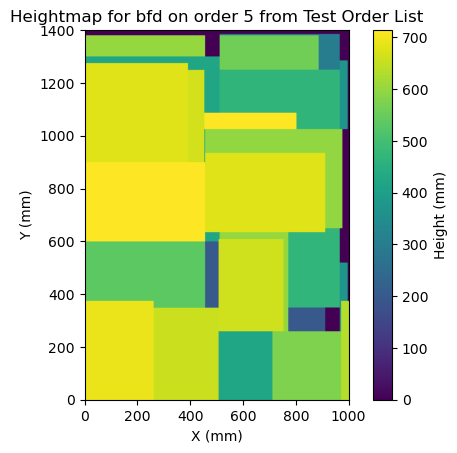

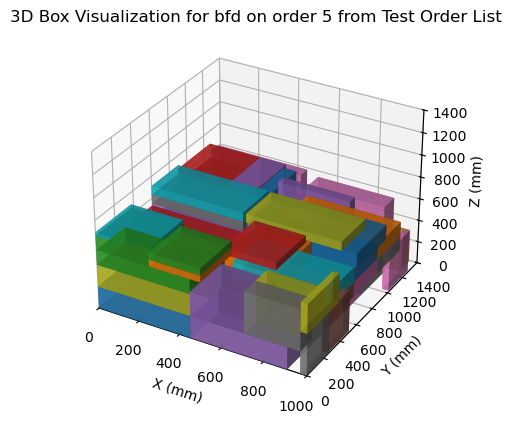

In [141]:
current_order_df = test_orders
current_orderID = 5
current_algo = "bfd"
current_metric = "maxz"

testpallet = process_order(current_orderID, algo=current_algo, order_df=current_order_df, metric=current_metric)
get_pallet_results(testpallet, current_algo, current_orderID, current_order_df, print_mode=True)